# Population and analysis-sample rebuild



In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
PACKAGE_ROOT = next(
    path for path in candidates
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
WILDFIRE_ROOT = PACKAGE_ROOT.parent
sys.path.insert(0, str(WILDFIRE_ROOT))

# Reuse the production DINS matcher from the main wildfire pipeline.
from src.features.dins import build as build_dins
# Reuse the OpenView graph/geometry adapters from the reproduction package.
from reviewer_reproduction.src.analysis.openview_3d_sen import (
    audit_openview_3d_run, build_analysis_from_openview_3d,
    load_county_buildings,
)
# Figures name their destination at the point of saving: this notebook is
# exploratory apart from the urban-depth panel, which goes to the manuscript.
from reviewer_reproduction.src.figure_paths import save_figure

FIRES = ('EATON', 'PALISADES')
OPENVIEW_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar',
))
RUN_TAG = 'openview3d_lariac6_2mi'
DERIVED = PACKAGE_ROOT / 'data' / 'derived' / RUN_TAG
BUILDING_CACHE = DERIVED / 'county_buildings.parquet'
DINS_PATH = DERIVED / 'dins_openview3d.parquet'
ANALYSIS_PATH = DERIVED / 'analysis_openview3d.parquet'
ORIGINAL_ANALYSIS_PATH = PACKAGE_ROOT / 'data' / 'analysis.parquet'
SECONDARY_ANALYSIS_PATH = DERIVED / 'analysis_openview3d_original_cohort.parquet'
SECONDARY_PAIRED_EXPOSED_PATH = DERIVED / 'analysis_openview3d_original_cohort_paired_exposed.parquet'
SECONDARY_AUDIT_PATH = DERIVED / 'analysis_openview3d_original_cohort_audit.csv'
VEGETATION_PATH = PACKAGE_ROOT / 'data' / 'enrichment' / 'vegetation.parquet'
DERIVED.mkdir(parents=True, exist_ok=True)
REBUILD_DINS = False

In [2]:
run_audit = audit_openview_3d_run(OPENVIEW_3D_RUN)
buildings = load_county_buildings(OPENVIEW_3D_RUN, BUILDING_CACHE)
assert buildings.building_id.is_unique
duplicate_source_ids = buildings.LARIAC_BLD_ID.duplicated(keep=False).sum()
display(run_audit)
print(f'Graph footprints: {len(buildings):,}')
print(f'Rows carrying a repeated source LARIAC ID: {duplicate_source_ids:,}')

,model,tiles,buildings,candidate_pairs,maximum_pair_distance_m,wui_buffer_m,terrain_resolution_m,source
0,differential_area_3d,1815,1628455,20164936,152.4,3218.688,30,/Users/adamswietek/Documents/PostDoc/data/raw_...


Graph footprints: 1,628,455
Rows carrying a repeated source LARIAC ID: 20,670


## Recompute the DINS crosswalk

`src.features.dins.build` reads the configured raw DINS CSV, filters to one incident, and snaps each inspection to the nearest graph-building centroid within 50 m. The closest inspection wins when more than one record maps to the same `BLD_ID`. Set `REBUILD_DINS=True` whenever the raw DINS file or graph footprints change.

In [3]:
if REBUILD_DINS or not DINS_PATH.exists():
    matched_parts = []
    base_spine = buildings.copy()
    # Match to the unique OpenView graph key. Source LARIAC IDs contain
    # true duplicates and cannot safely identify the nearest footprint.
    base_spine['BLD_ID'] = base_spine.building_id.astype(str)
    base_spine['has_id'] = True
    for fire in FIRES:
        # One incident at a time preserves the fire label while searching
        # against every footprint represented in the completed graph.
        fire_spine = base_spine.assign(fire=fire)
        matched = build_dins(fire_spine)
        matched = matched.rename(columns={'BLD_ID': 'graph_id'})
        matched['graph_id'] = matched.graph_id.astype('int64')
        matched['fire'] = fire
        matched_parts.append(matched)
    dins = pd.concat(matched_parts, ignore_index=True)
    assert not dins.duplicated(['fire', 'graph_id']).any()
    dins.to_parquet(DINS_PATH, index=False)
else:
    dins = pd.read_parquet(DINS_PATH)
print(f'DINS-to-graph matches: {len(dins):,} -> {DINS_PATH}')

DINS-to-graph matches: 28,297 -> /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/dins_openview3d.parquet


## Build the analysis-ready table

For each assessed receiver, the adapter sums its stored directional view factors from DINS-destroyed emitting neighbors. The resulting `dose_sum` is also exposed as `F_destroyed_wmean` for compatibility with the existing fragility functions. Because `vf_i_to_j` is already exchange area divided by receiver facade area, it is not area-averaged again. `dose_max_pair` retains the largest destroyed-neighbor contribution.

In [5]:
analysis = build_analysis_from_openview_3d(
    OPENVIEW_3D_RUN, buildings, dins, ANALYSIS_PATH,
    vegetation_path=VEGETATION_PATH,
)
assert analysis.graph_id.is_unique
assert analysis.BLD_ID.is_unique
assert analysis.dose_sum.ge(analysis.dose_max_pair - 1e-12).all()
print(f'Analysis-ready rows: {len(analysis):,} -> {ANALYSIS_PATH}')

Analysis-ready rows: 28,257 -> /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/analysis_openview3d.parquet


## Secondary analysis: original cohort with OpenView graph exposure

The primary table above independently rematches DINS inspections to the OpenView graph and is appropriate for a complete OpenView rebuild. For a controlled secondary analysis, the table below instead locks the population, outcomes, construction attributes, defense variables, vegetation covariates, and spatial bootstrap groups to the original analysis sample. It replaces only the exposure calculation with the stored OpenView building-to-building graph values.

All original rows are retained. Exact fire/building matches receive OpenView graph identifiers and exposure fields; unmatched rows retain missing exposure values and are explicitly flagged rather than being interpreted as zero exposure. The full product supports population and missingness audits. A second paired-exposed product contains only buildings with positive exposure under both calculations and is the strict like-for-like input for parallel versions of notebooks 01–03.

In [5]:
original_analysis = pd.read_parquet(ORIGINAL_ANALYSIS_PATH).copy()
for frame in (original_analysis, analysis):
    frame['BLD_ID'] = frame.BLD_ID.astype(str)
    frame['fire'] = frame.fire.astype(str).str.upper()
key = ['fire', 'BLD_ID']
assert not original_analysis.duplicated(key).any()
assert not analysis.duplicated(key).any()

# Preserve the original exposure fields for paired diagnostics while giving
# their conventional names to the OpenView graph values used downstream.
original_exposure_columns = [
    name for name in (
        'F_destroyed_wmean', 'F_upfire_wmean',
        'F_upfire_interp_wmean', 'log_dose', 'exposed',
    ) if name in original_analysis.columns
]
secondary = original_analysis.rename(columns={
    name: f'{name}_original' for name in original_exposure_columns
})
attachment_columns = key + [
    'graph_id', 'source_BLD_ID', 'graph_neighbors',
    'outcome_known_neighbors', 'n_destroyed_bldgs', 'F_total_wmean',
    'dose_sum', 'dose_max_pair', 'F_partial_wmean',
    'F_no_damage_wmean', 'F_destroyed_wmean', 'log_dose', 'exposed',
    'outcome', 'any_damage', 'is_destroyed',
]
attachment = analysis[attachment_columns].rename(columns={
    'outcome': 'outcome_openview3d_check',
    'any_damage': 'any_damage_openview3d_check',
    'is_destroyed': 'is_destroyed_openview3d_check',
})
secondary = secondary.merge(
    attachment, on=key, how='left', validate='one_to_one', indicator=True,
)
secondary['openview_graph_match'] = secondary._merge.eq('both')
for outcome_column in ('outcome', 'any_damage', 'is_destroyed'):
    check_column = f'{outcome_column}_openview3d_check'
    assert secondary.loc[
        secondary.openview_graph_match, outcome_column
    ].eq(secondary.loc[secondary.openview_graph_match, check_column]).all()
secondary = secondary.drop(columns=[
    '_merge', 'outcome_openview3d_check', 'any_damage_openview3d_check',
    'is_destroyed_openview3d_check',
])
secondary['exposed'] = secondary.exposed.fillna(0).astype('int8')
secondary['positive_openview3d_exposure'] = (
    secondary.openview_graph_match & secondary.F_destroyed_wmean.gt(0)
)
secondary['positive_original_exposure'] = secondary.F_destroyed_wmean_original.gt(0)
secondary['paired_positive_exposure'] = (
    secondary.positive_original_exposure
    & secondary.positive_openview3d_exposure
)
secondary['analysis_variant'] = 'original_cohort_openview3d_exposure'
assert len(secondary) == len(original_analysis)
assert not secondary.duplicated(key).any()
secondary.to_parquet(SECONDARY_ANALYSIS_PATH, index=False)
secondary.loc[secondary.paired_positive_exposure].to_parquet(
    SECONDARY_PAIRED_EXPOSED_PATH, index=False,
)

audit_rows = []
for fire in (*FIRES, 'POOLED'):
    subset = secondary if fire == 'POOLED' else secondary[secondary.fire.eq(fire)]
    original_positive = subset.F_destroyed_wmean_original.gt(0)
    new_positive = subset.F_destroyed_wmean.gt(0)
    audit_rows.append({
        'fire': fire, 'original_rows_retained': len(subset),
        'exact_openview_graph_matches': int(subset.openview_graph_match.sum()),
        'unmatched_rows': int((~subset.openview_graph_match).sum()),
        'original_positive_exposure': int(original_positive.sum()),
        'openview_positive_exposure': int(new_positive.sum()),
        'positive_exposure_in_both': int((original_positive & new_positive).sum()),
        'matched_zero_openview_exposure': int((
            subset.openview_graph_match & ~new_positive
        ).sum()),
    })
secondary_audit = pd.DataFrame(audit_rows)
secondary_audit.to_csv(SECONDARY_AUDIT_PATH, index=False)
print(f'Secondary analysis rows: {len(secondary):,} -> {SECONDARY_ANALYSIS_PATH}')
print(
    f'Paired positive-exposure rows: {secondary.paired_positive_exposure.sum():,} '
    f'-> {SECONDARY_PAIRED_EXPOSED_PATH}'
)
display(secondary_audit)

Secondary analysis rows: 28,208 -> /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/analysis_openview3d_original_cohort.parquet
Paired positive-exposure rows: 23,997 -> /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/data/derived/openview3d_lariac6_2mi/analysis_openview3d_original_cohort_paired_exposed.parquet


,fire,original_rows_retained,exact_openview_graph_matches,unmatched_rows,original_positive_exposure,openview_positive_exposure,positive_exposure_in_both,matched_zero_openview_exposure
0,EATON,16851,16816,35,14595,14205,13996,2611
1,PALISADES,11357,11301,56,10532,10034,10001,1267
2,POOLED,28208,28117,91,25127,24239,23997,3878


In [6]:
population = (
    analysis.groupby('fire', observed=True)
    .agg(
        assessed=('BLD_ID', 'size'),
        survived=('outcome', lambda x: int(x.eq('no_damage').sum())),
        partial=('outcome', lambda x: int(x.eq('partial').sum())),
        destroyed=('is_destroyed', 'sum'),
        positive_destroyed_neighbor_exposure=(
            'F_destroyed_wmean', lambda x: int(x.gt(0).sum())
        ),
        median_graph_neighbors=('graph_neighbors', 'median'),
        median_known_outcome_neighbors=('outcome_known_neighbors', 'median'),
    )
    .reset_index()
)
display(population)
display(pd.crosstab(analysis.fire, analysis.outcome, margins=True))

,fire,assessed,survived,partial,destroyed,positive_destroyed_neighbor_exposure,median_graph_neighbors,median_known_outcome_neighbors
0,EATON,16868,7270,1002,8596,14216,29.0,26.0
1,PALISADES,11389,3936,924,6529,10061,23.0,22.0


outcome,destroyed,no_damage,partial,All
fire,,,,
EATON,8596,7270,1002,16868
PALISADES,6529,3936,924,11389
All,15125,11206,1926,28257


In [21]:
analysis.columns

Index(['graph_id', 'dins_dist_m', 'defense_action', 'damage',
       'roof_construction', 'eaves', 'vent_screen', 'exterior_siding',
       'window_pane', 'year_built', 'apn', 'is_defended', 'fire', 'outcome',
       'any_damage', 'is_destroyed', 'source_BLD_ID', 'BLD_ID',
       'graph_neighbors', 'outcome_known_neighbors', 'n_destroyed_bldgs',
       'F_total_wmean', 'dose_sum', 'dose_max_pair', 'F_partial_wmean',
       'F_no_damage_wmean', 'F_destroyed_wmean', 'log_dose', 'exposed',
       'roof_class', 'defended', 'lon_wgs84', 'lat_wgs84', 'grid_id',
       'ndvi_mean', 'veg_frac', 'shrub_frac', 'has_ndvi'],
      dtype='object')

In [22]:
(analysis
 .query('F_destroyed_wmean > 0')
 .groupby('defended').size())

defended
False    23021
True      1256
dtype: int64

In [7]:
analysis.query('F_destroyed_wmean > 0').groupby(['fire','outcome'], observed=True).size().unstack()

outcome,destroyed,no_damage,partial
fire,,,
EATON,8553,4724,939
PALISADES,6443,2753,865


## Total geometric coupling in the fire samples and county graph

The county remainder has no DINS outcome labels, so destruction-weighted $F^*$ (`F_destroyed_wmean`) cannot be calculated for it. This comparison instead uses the common all-neighbor building view factor: `analysis.F_total_wmean` for assessed Eaton and Palisades structures and the exactly equivalent `building_metrics.bvf_all_edges` for all other buildings in the completed LA County two-mile-WUI run. The ECDF is preferable to raw-count histograms here because the county remainder is much larger than either assessed fire sample.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
from reviewer_reproduction.src.viz.style import FIRE_COLORS, apply_style

apply_style()
BUILDING_METRICS_PATH = OPENVIEW_3D_RUN / 'building_metrics.parquet'
building_metrics = pd.read_parquet(
    BUILDING_METRICS_PATH, columns=['building_id', 'bvf_all_edges'],
)
assert building_metrics.building_id.is_unique

# Confirm that both tables refer to the same receiver-normalized score.
assessed_check = analysis[['graph_id', 'F_total_wmean']].merge(
    building_metrics, left_on='graph_id', right_on='building_id',
    how='left', validate='one_to_one',
)
assert np.allclose(
    assessed_check.F_total_wmean, assessed_check.bvf_all_edges,
    rtol=1e-10, atol=1e-12,
)

assessed_ids = pd.Index(analysis.graph_id.unique())
county_remainder = building_metrics.loc[
    ~building_metrics.building_id.isin(assessed_ids), 'bvf_all_edges'
]
f_groups = {
    'Eaton assessed': analysis.loc[analysis.fire.eq('EATON'), 'F_total_wmean'],
    'Palisades assessed': analysis.loc[analysis.fire.eq('PALISADES'), 'F_total_wmean'],
    'County-run remainder': county_remainder,
}
colors = {
    'Eaton assessed': FIRE_COLORS['EATON'],
    'Palisades assessed': FIRE_COLORS['PALISADES'],
    'County-run remainder': '#666666',
}

summary_rows, ecdf_rows = [], []
fig, ax = plt.subplots(figsize=(6.6, 4.1))
for label, values in f_groups.items():
    values = values.dropna().to_numpy(float)
    ordered = np.sort(values)
    # Preserve the exact distribution while limiting rendered vertices.
    positions = np.linspace(0, len(ordered) - 1, min(5_000, len(ordered)), dtype=int)
    zero_count = int(np.count_nonzero(ordered == 0))
    if zero_count:
        positions = np.unique(np.r_[positions, zero_count - 1])
    x = ordered[positions]
    cumulative = (positions + 1) / len(ordered)
    ax.step(
        x, cumulative, where='post', color=colors[label], linewidth=2.0,
        label=f'{label} (n={len(ordered):,})',
    )
    ecdf_rows.extend({
        'population': label, 'F_total': x_value, 'cumulative_probability': p,
        'population_n': len(ordered),
    } for x_value, p in zip(x, cumulative))
    summary_rows.append({
        'population': label, 'n': len(ordered),
        'zero_F_share': np.mean(values == 0),
        'mean_F_total': np.mean(values),
        'median_F_total': np.median(values),
        'p90_F_total': np.quantile(values, 0.90),
        'p95_F_total': np.quantile(values, 0.95),
        'p99_F_total': np.quantile(values, 0.99),
    })

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel(r'All-neighbor geometric coupling, $F_{total}$')
ax.set_ylabel('Cumulative share of buildings')
ax.set_title('Total 3D coupling across fire samples and county run', loc='left',
             fontweight='bold')
ax.grid(True, color='#E8E8E8', linewidth=0.5)
ax.legend(loc='lower right')
fig.tight_layout()

population_f_summary = pd.DataFrame(summary_rows)
population_f_ecdf = pd.DataFrame(ecdf_rows)
population_f_summary.to_csv(
    DERIVED / 'population_F_total_summary_openview3d.csv', index=False,
)
population_f_ecdf.to_csv(
    DERIVED / 'population_F_total_ecdf_openview3d_source.csv', index=False,
)
save_figure(fig, 'population_F_total_ecdf_openview3d', 'exploratory')
display(population_f_summary.round(4))
fig

NameError: name 'analysis' is not defined

/Users/adamswietek/opt/anaconda3/envs/openview/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


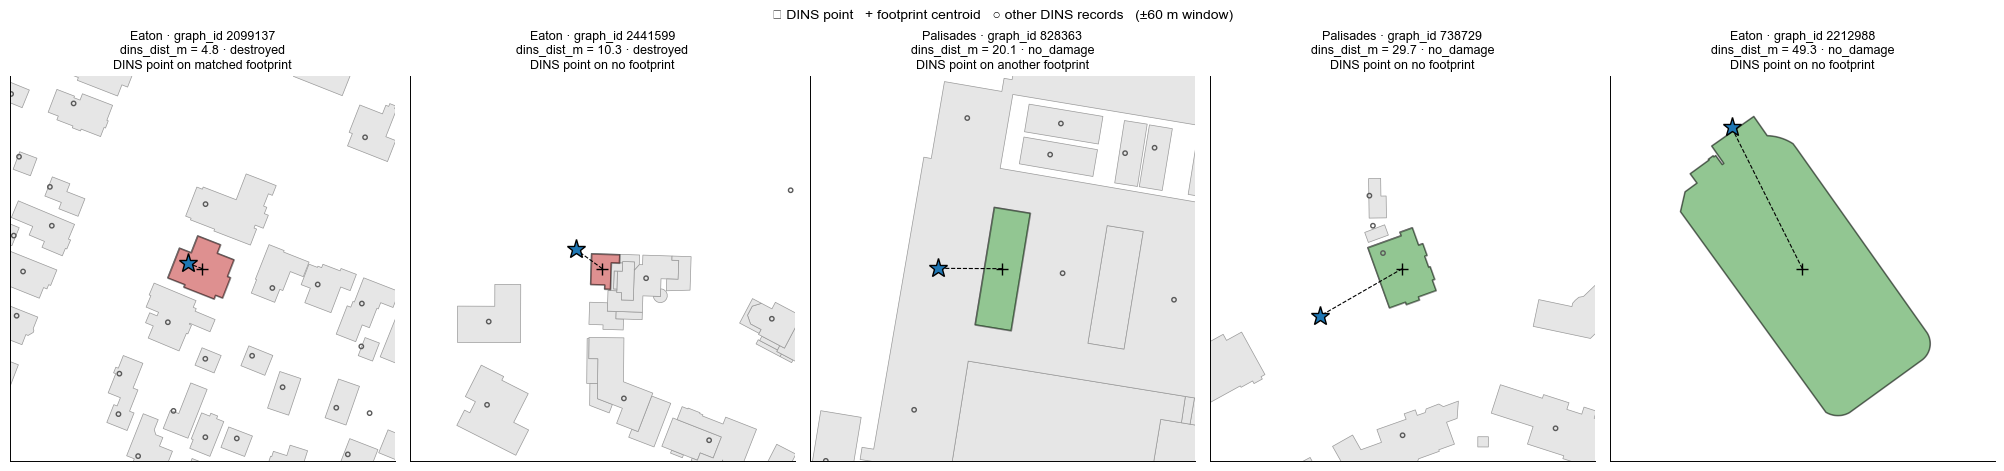

,target_m,fire,graph_id,dins_dist_m,outcome
0,5,EATON,2099137,4.829671,destroyed
1,10,EATON,2441599,10.282147,destroyed
2,20,PALISADES,828363,20.071369,no_damage
3,30,PALISADES,738729,29.745746,no_damage
4,50,EATON,2212988,49.330382,no_damage


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from src.config import DINS_CSV

TARGETS_M = (5, 10, 20, 30, 50)
HALF_WINDOW_M = 60
SEED = 0
INCIDENT = {'EATON': 'Eaton', 'PALISADES': 'Palisades'}
OUTCOME_COLOR = {'destroyed': 'tab:red', 'partial': 'tab:orange',
                 'no_damage': 'tab:green'}

# One assessed building per target distance (random among those within
# 0.5 m of the target; nearest available if none, e.g. at the 50 m cap).
examples = []
for target in TARGETS_M:
    gap = analysis.dins_dist_m.sub(target).abs()
    pool = analysis[gap < 0.5]
    row = (pool.sample(1, random_state=SEED) if len(pool)
           else analysis.loc[[gap.idxmin()]])
    examples.append(row.assign(target_m=target))
examples = pd.concat(examples, ignore_index=True)

# The crosswalk keeps dins_dist_m but not the DINS coordinates, so recover
# the matched record from the raw CSV: same incident, same distance to the
# footprint centroid the matcher used.
raw = pd.read_csv(
    DINS_CSV, low_memory=False,
    usecols=['Latitude', 'Longitude', '* Incident Name', '* Damage'],
).dropna(subset=['Latitude', 'Longitude'])
raw = gpd.GeoDataFrame(
    raw, geometry=gpd.points_from_xy(raw.Longitude, raw.Latitude),
    crs='EPSG:4326',
).to_crs(buildings.crs)
footprints = buildings.set_index('building_id').geometry

fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 4.6),
                         layout='constrained')
for ax, ex in zip(axes, examples.itertuples()):
    shape = footprints.loc[ex.graph_id]
    centroid = shape.centroid
    window = box(centroid.x - HALF_WINDOW_M, centroid.y - HALF_WINDOW_M,
                 centroid.x + HALF_WINDOW_M, centroid.y + HALF_WINDOW_M)

    fire_dins = raw[raw['* Incident Name'].eq(INCIDENT[ex.fire])]
    nearby = fire_dins.iloc[fire_dins.sindex.query(window)]
    residual = nearby.distance(centroid).sub(ex.dins_dist_m).abs()
    dins_pt = nearby.geometry.loc[residual.idxmin()]
    assert residual.min() < 1e-3, f'no DINS record reproduces {ex.graph_id}'

    context = buildings.iloc[buildings.sindex.query(window)]
    context.plot(ax=ax, facecolor='0.9', edgecolor='0.6', linewidth=0.5)
    gpd.GeoSeries([shape]).plot(
        ax=ax, facecolor=OUTCOME_COLOR.get(ex.outcome, 'tab:blue'),
        alpha=0.45, edgecolor='k', linewidth=1.2,
    )
    others = nearby.drop(residual.idxmin())
    if len(others):
        others.plot(ax=ax, marker='o', markersize=10, facecolor='none',
                    edgecolor='0.35')
    ax.plot([centroid.x, dins_pt.x], [centroid.y, dins_pt.y], 'k--', lw=0.8)
    ax.plot(centroid.x, centroid.y, 'k+', ms=9)
    ax.plot(dins_pt.x, dins_pt.y, marker='*', ms=14, color='tab:blue',
            markeredgecolor='k')
    # Does the DINS point sit on the matched footprint, another one, or none?
    if shape.contains(dins_pt):
        lands_on = 'matched footprint'
    elif context.contains(dins_pt).any():
        lands_on = 'another footprint'
    else:
        lands_on = 'no footprint'
    ax.set_xlim(window.bounds[0], window.bounds[2])
    ax.set_ylim(window.bounds[1], window.bounds[3])
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{ex.fire.title()} · graph_id {ex.graph_id}\n'
                 f'dins_dist_m = {ex.dins_dist_m:.1f} · {ex.outcome}\n'
                 f'DINS point on {lands_on}', fontsize=9)
fig.suptitle('★ DINS point   + footprint centroid   ○ other DINS records   '
             f'(±{HALF_WINDOW_M} m window)', fontsize=10)
plt.show()
display(examples[['target_m', 'fire', 'graph_id', 'dins_dist_m', 'outcome']])

## Urban depth and shared neighborhood loss

Rebuilds the ED02 proximity figure (`notebooks/extended_data/ED02_fragility_sensitivity.ipynb`) on the assessed population above: OpenView 3D graph footprints joined through the recomputed DINS crosswalk. Urban depth is the footprint-centroid distance to the CAL FIRE Influence Zone boundary after clipping to the fire perimeter and a 100 m morphological opening; this definition reproduces the packaged `ED_fig_urban_depth_maps_source.csv` to within a metre at the median. Assessed neighbors lie within 100 ft surface-to-surface, excluding the focal footprint. Profiles use 16 equal-count log-depth bins per fire, with 95% intervals clustered by 250 m grid cell. Outputs carry an `_openview3d` suffix so they do not overwrite the packaged ED02 files.

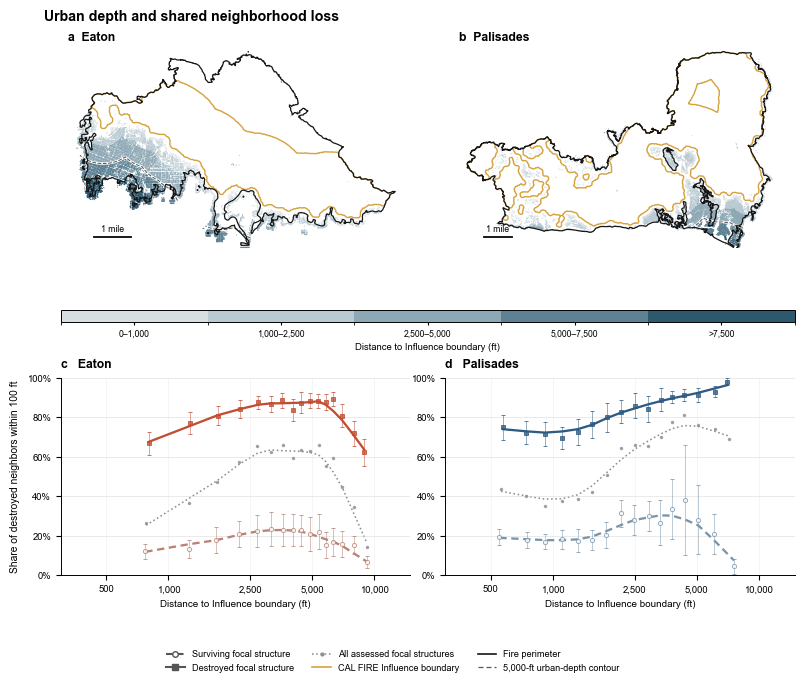

,fire,assessed_buildings,buildings_with_assessed_neighbor,coverage_share,median_assessed_neighbors,mean_assessed_neighbors
0,EATON,16868,16774,0.994,8.0,8.261
1,PALISADES,11389,11063,0.971,7.0,7.354


,metric,fire,matched_depth_bins_openview3d,destroyed_survived_neighbor_gap_pp_openview3d,matched_depth_bins_packaged,destroyed_survived_neighbor_gap_pp_packaged
0,dist_to_opened_influence_boundary_m,EATON,16,63.77,16,63.75
1,dist_to_opened_influence_boundary_m,PALISADES,16,59.50,16,59.46


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig1_urban_depth_shared_neighborhood_loss.png


In [11]:
# Urban depth and shared neighborhood loss (ED02 figure), rebuilt on the
# OpenView 3D assessed population: graph footprints joined through the DINS
# crosswalk above, rather than the packaged nx footprints and BLD_IDs.
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import shapely
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedFormatter, FixedLocator, PercentFormatter
from statsmodels.nonparametric.smoothers_lowess import lowess
from reviewer_reproduction.src.viz.style import (
    FIRE_COLORS, WUI_INFLUENCE_COLOR, apply_style,
)

apply_style()
DATA = PACKAGE_ROOT / 'data'
FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
FIGURES.mkdir(parents=True, exist_ok=True)
FIRE_COLOR = FIRE_COLORS
M_TO_FT = 3.28084
M_PER_MI = 1609.344
INFLUENCE_OPENING_M = 100.0
assert buildings.crs.to_epsg() == 26911

# Urban depth: centroid distance to the fire-clipped Influence Zone boundary
# after a 100 m morphological opening. This reproduces the packaged
# ED_fig_urban_depth_maps_source.csv (median absolute difference < 1 m).
wui_zones = gpd.read_file(DATA / 'calfire_wui_la.gpkg').to_crs(26911)
influence_zone = wui_zones[wui_zones.WUI_DESC.eq('Influence Zone')]
fire_perimeters_depth = (
    gpd.read_parquet(DATA / 'nx' / 'fire_perims.parquet')
    .to_crs(26911).set_index('FIRE_NAME'))
graph_footprints = buildings.set_index('building_id').geometry
opened_influence_zones, depth_parts = {}, []
for fire_name in FIRES:
    clipped = shapely.intersection(
        influence_zone.geometry.union_all(),
        fire_perimeters_depth.loc[fire_name].geometry)
    opened = shapely.buffer(
        shapely.buffer(clipped, -INFLUENCE_OPENING_M), INFLUENCE_OPENING_M)
    opened_influence_zones[fire_name] = gpd.GeoSeries([opened], crs=26911)
    assessed = analysis.loc[analysis.fire.eq(fire_name), [
        'BLD_ID', 'graph_id', 'fire', 'is_destroyed', 'grid_id']]
    part = gpd.GeoDataFrame(
        assessed, crs=26911,
        geometry=graph_footprints.loc[assessed.graph_id].to_numpy())
    part['dist_to_opened_influence_boundary_m'] = (
        part.geometry.centroid.distance(opened.boundary))
    depth_parts.append(part)
urban_depth_buildings = gpd.GeoDataFrame(
    pd.concat(depth_parts, ignore_index=True), geometry='geometry', crs=26911)

NEIGHBOR_RADIUS_FT = 100
NEIGHBOR_RADIUS_M = NEIGHBOR_RADIUS_FT / M_TO_FT
DEPTH_CONTOUR_FT = 5000
DEPTH_CONTOUR_MAX_EDGE_M = 500
DEPTH_DISPLAY = {
    'dist_to_opened_influence_boundary_m': {
        'label': 'Distance to Influence boundary (ft)',
        'ticks': [500, 1000, 2500, 5000, 10000],
        'xlim': (300, 15000),
    },
}
OUTCOME_STYLE = {
    0: {'label': 'Surviving focal structure', 'marker': 'o', 'ls': (0, (3.2, 2.0)),
        'filled': False, 'color': '#4F7185'},
    1: {'label': 'Destroyed focal structure', 'marker': 's', 'ls': '-',
        'filled': True, 'color': '#A64B3C'},
}
ALL_ASSESSED_COLOR = '#8F8F8F'

# Assessed neighbors within 100 ft surface-to-surface, focal excluded.
neighbor_parts, neighbor_coverage_rows = [], []
for fire_name in FIRES:
    fire_buildings = urban_depth_buildings[
        urban_depth_buildings.fire.eq(fire_name)].copy().reset_index(drop=True)
    pair_idx = fire_buildings.sindex.query(
        fire_buildings.geometry, predicate='dwithin',
        distance=NEIGHBOR_RADIUS_M)
    keep = pair_idx[0] != pair_idx[1]
    focal_i, neighbor_i = pair_idx[0, keep], pair_idx[1, keep]
    neighbor_count = np.bincount(
        focal_i, minlength=len(fire_buildings)).astype(int)
    destroyed_count = np.bincount(
        focal_i,
        weights=fire_buildings.is_destroyed.to_numpy(float)[neighbor_i],
        minlength=len(fire_buildings))
    fire_buildings['assessed_neighbors_100ft'] = neighbor_count
    fire_buildings['destroyed_neighbors_100ft'] = destroyed_count.astype(int)
    fire_buildings['destroyed_neighbor_share_100ft'] = np.divide(
        destroyed_count, neighbor_count,
        out=np.full(len(fire_buildings), np.nan, dtype=float),
        where=neighbor_count > 0)
    valid = neighbor_count > 0
    neighbor_coverage_rows.append({
        'fire': fire_name, 'assessed_buildings': len(fire_buildings),
        'buildings_with_assessed_neighbor': int(valid.sum()),
        'coverage_share': float(valid.mean()),
        'median_assessed_neighbors': float(np.median(neighbor_count[valid])),
        'mean_assessed_neighbors': float(np.mean(neighbor_count[valid])),
    })
    neighbor_parts.append(pd.DataFrame(fire_buildings.drop(columns='geometry')))

proximity_outcomes = pd.concat(neighbor_parts, ignore_index=True)
proximity_coverage = pd.DataFrame(neighbor_coverage_rows)
profile_rows, pooled_profile_rows, gap_rows = [], [], []
for metric, metric_spec in DEPTH_DISPLAY.items():
    for fire_name in FIRES:
        z = proximity_outcomes.dropna(
            subset=[metric, 'destroyed_neighbor_share_100ft'])
        z = z[z.fire.eq(fire_name) & z[metric].gt(0)].copy()
        z['depth_ft'] = z[metric] * M_TO_FT
        z['ln_depth'] = np.log(z.depth_ft)
        z['depth_bin'] = pd.qcut(
            z.ln_depth, 16, labels=False, duplicates='drop')
        # The reference series pools the same focal population over outcome.
        for depth_bin, group in z.groupby('depth_bin', observed=True):
            pooled_profile_rows.append({
                'metric': metric, 'fire': fire_name,
                'depth_bin': int(depth_bin), 'buildings': len(group),
                'depth_ft': np.exp(group.ln_depth.mean()),
                'ln_depth': group.ln_depth.mean(),
                'destroyed_neighbor_share_100ft':
                    group.destroyed_neighbor_share_100ft.mean(),
                'mean_assessed_neighbors':
                    group.assessed_neighbors_100ft.mean(),
            })
        fire_rows = []
        for (damage, depth_bin), group in z.groupby(
                ['is_destroyed', 'depth_bin'], observed=True):
            if len(group) < 30:
                continue
            y = group.destroyed_neighbor_share_100ft.to_numpy(float)
            ybar = float(np.mean(y))
            # Standard errors clustered by ~250 m grid cell.
            cluster = group.grid_id.fillna(group.BLD_ID).astype(str)
            scores = (pd.Series(y - ybar, index=group.index)
                      .groupby(cluster).sum().to_numpy())
            n_clusters = len(scores)
            se = (np.sqrt(
                n_clusters / (n_clusters - 1)
                * np.sum(scores ** 2) / len(group) ** 2)
                  if n_clusters > 1 else np.nan)
            row = {
                'metric': metric, 'fire': fire_name,
                'is_destroyed': int(damage), 'depth_bin': int(depth_bin),
                'buildings': len(group), 'clusters_250m': n_clusters,
                'depth_ft': np.exp(group.ln_depth.mean()),
                'destroyed_neighbor_share_100ft': ybar,
                'share_lo': max(0, ybar - 1.96 * se),
                'share_hi': min(1, ybar + 1.96 * se),
                'mean_assessed_neighbors': group.assessed_neighbors_100ft.mean(),
                'ln_depth': group.ln_depth.mean(),
            }
            fire_rows.append(row); profile_rows.append(row)
        fire_profile = pd.DataFrame(fire_rows)
        paired = fire_profile.pivot(
            index='depth_bin', columns='is_destroyed',
            values='destroyed_neighbor_share_100ft').dropna()
        gap_rows.append({
            'metric': metric, 'fire': fire_name,
            'matched_depth_bins': len(paired),
            'destroyed_survived_neighbor_gap_pp':
                float(100 * (paired[1] - paired[0]).mean()),
        })

proximity_profile = pd.DataFrame(profile_rows)
all_assessed_profile = pd.DataFrame(pooled_profile_rows)
proximity_gap = pd.DataFrame(gap_rows)
urban_depth_buildings[['BLD_ID', 'graph_id', 'fire', *DEPTH_DISPLAY]].to_csv(
    DERIVED / 'ED_fig_urban_depth_maps_openview3d_source.csv', index=False)
proximity_coverage.to_csv(
    DERIVED / 'proximity_neighbor_coverage_100ft_openview3d.csv', index=False)
proximity_gap.to_csv(
    DERIVED / 'proximity_shared_loss_gaps_openview3d.csv', index=False)
proximity_profile.to_csv(
    DERIVED / 'ED_fig_proximity_shared_loss_openview3d_source.csv', index=False)
all_assessed_profile.to_csv(
    DERIVED / 'ED_fig_proximity_all_assessed_openview3d_source.csv', index=False)

fig = plt.figure(figsize=(8.2, 6.8))
grid = fig.add_gridspec(3, 2, height_ratios=[1.02, .055, .96],
                        hspace=.40, wspace=.10)
axes = np.array([[fig.add_subplot(grid[0, 0]),
                  fig.add_subplot(grid[0, 1])],
                 [fig.add_subplot(grid[2, 0]),
                  fig.add_subplot(grid[2, 1])]])
colorbar_ax = fig.add_subplot(grid[1, :])
map_metric = 'dist_to_opened_influence_boundary_m'
DEPTH_BINS_FT = np.array([0, 1000, 2500, 5000, 7500, 10000])
MAP_COLORS = ['#D7DEE1', '#B9CAD2', '#8EA9B6', '#5D8294', '#2D596E']
map_cmap = ListedColormap(MAP_COLORS)
map_norm = BoundaryNorm(DEPTH_BINS_FT, map_cmap.N, clip=True)
FIRE_LIGHT = {'EATON': '#B98274', 'PALISADES': '#7895AB'}
for col_i, fire_name in enumerate(FIRES):
    ax = axes[0, col_i]
    sub = urban_depth_buildings[
        urban_depth_buildings.fire.eq(fire_name)].copy()
    sub['_depth_ft'] = sub[map_metric] * M_TO_FT
    values_ft = sub['_depth_ft'].to_numpy(float)
    # One centroid per assessed structure stays legible at fire extent.
    sub_points = sub.copy()
    sub_points.geometry = sub.geometry.centroid
    sub_points.plot(
        ax=ax, column='_depth_ft', cmap=map_cmap, norm=map_norm,
        marker='o', markersize=.45, linewidth=0, edgecolor='none',
        alpha=.92, rasterized=True, zorder=2)
    opened_influence_zones[fire_name].boundary.plot(
        ax=ax, color=WUI_INFLUENCE_COLOR, lw=1.0, zorder=4)
    # Haloed 5,000-ft isodepth interpolated over assessed-building
    # locations; long-edge triangles are masked so the contour does not
    # bridge disconnected neighborhoods.
    contour_x = sub_points.geometry.x.to_numpy(float)
    contour_y = sub_points.geometry.y.to_numpy(float)
    contour_valid = (np.isfinite(contour_x) & np.isfinite(contour_y)
                     & np.isfinite(values_ft))
    contour_values = values_ft[contour_valid]
    triangulation = mtri.Triangulation(
        contour_x[contour_valid], contour_y[contour_valid])
    triangle_xy = np.stack([
        triangulation.x[triangulation.triangles],
        triangulation.y[triangulation.triangles]], axis=2)
    triangle_edges = np.stack([
        triangle_xy[:, 1] - triangle_xy[:, 0],
        triangle_xy[:, 2] - triangle_xy[:, 1],
        triangle_xy[:, 0] - triangle_xy[:, 2]], axis=1)
    longest_edge = np.sqrt((triangle_edges ** 2).sum(axis=2)).max(axis=1)
    triangulation.set_mask(longest_edge > DEPTH_CONTOUR_MAX_EDGE_M)
    if contour_values.min() <= DEPTH_CONTOUR_FT <= contour_values.max():
        ax.tricontour(
            triangulation, contour_values, levels=[DEPTH_CONTOUR_FT],
            colors='white', linewidths=1.8, zorder=4.8)
        ax.tricontour(
            triangulation, contour_values, levels=[DEPTH_CONTOUR_FT],
            colors='#555555', linewidths=.72,
            linestyles='dashed', zorder=5.0)
    gpd.GeoSeries([fire_perimeters_depth.loc[fire_name].geometry],
                  crs=26911).boundary.plot(
        ax=ax, color='#161616', lw=.9, zorder=6)
    # Keep the full fire perimeter in view, not just the building extent.
    building_bounds = sub.total_bounds
    perimeter_bounds = np.asarray(
        fire_perimeters_depth.loc[fire_name].geometry.bounds)
    xmin = min(building_bounds[0], perimeter_bounds[0])
    ymin = min(building_bounds[1], perimeter_bounds[1])
    xmax = max(building_bounds[2], perimeter_bounds[2])
    ymax = max(building_bounds[3], perimeter_bounds[3])
    xpad, ypad = .025 * (xmax - xmin), .035 * (ymax - ymin)
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_title(f'{"ab"[col_i]}  {fire_name.title()}', loc='left',
                 fontsize=8.8, fontweight='bold', pad=3)
    bar_x0 = xmin + .055 * (xmax - xmin)
    bar_y = ymin + .055 * (ymax - ymin)
    ax.plot([bar_x0, bar_x0 + M_PER_MI], [bar_y, bar_y],
            color='#111111', lw=1.35, zorder=7)
    ax.text(bar_x0 + M_PER_MI / 2, bar_y + .018 * (ymax - ymin),
            '1 mile', ha='center', va='bottom', fontsize=6.2)
depth_cbar = fig.colorbar(
    ScalarMappable(norm=map_norm, cmap=map_cmap), cax=colorbar_ax,
    orientation='horizontal',
    ticks=[500, 1750, 3750, 6250, 8750])
depth_cbar.set_label('Distance to Influence boundary (ft)',
                     fontsize=6.8, labelpad=3)
depth_cbar.ax.tick_params(labelsize=6.2, length=2)
depth_cbar.ax.set_xticklabels(
    ['0–1,000', '1,000–2,500', '2,500–5,000',
     '5,000–7,500', '>7,500'])
for metric, metric_spec in DEPTH_DISPLAY.items():
    for col_i, fire_name in enumerate(FIRES):
        ax = axes[1, col_i]
        panel = proximity_profile[
            proximity_profile.metric.eq(metric)
            & proximity_profile.fire.eq(fire_name)]
        background = all_assessed_profile[
            all_assessed_profile.fire.eq(fire_name)
            & all_assessed_profile.metric.eq(metric)
        ].sort_values('depth_ft')
        background_smooth = lowess(
            background.destroyed_neighbor_share_100ft,
            background.ln_depth, frac=.45, return_sorted=True)
        ax.plot(np.exp(background_smooth[:, 0]),
                np.clip(background_smooth[:, 1], 0, 1),
                color=ALL_ASSESSED_COLOR, lw=1.15, ls=':', zorder=1)
        ax.plot(background.depth_ft,
                background.destroyed_neighbor_share_100ft,
                marker='.', ms=3.0, lw=0, color=ALL_ASSESSED_COLOR,
                alpha=.75, zorder=2)
        for damage in [0, 1]:
            style = OUTCOME_STYLE[damage]
            series_color = (FIRE_COLOR[fire_name] if damage == 1
                            else FIRE_LIGHT[fire_name])
            group = panel[
                panel.is_destroyed.eq(damage)].sort_values('depth_ft')
            smooth = lowess(
                group.destroyed_neighbor_share_100ft, group.ln_depth,
                frac=.45, return_sorted=True)
            ax.plot(np.exp(smooth[:, 0]), np.clip(smooth[:, 1], 0, 1),
                    color=series_color, ls=style['ls'], lw=1.65, zorder=3)
            yerr = np.vstack([
                group.destroyed_neighbor_share_100ft - group.share_lo,
                group.share_hi - group.destroyed_neighbor_share_100ft])
            ax.errorbar(
                group.depth_ft, group.destroyed_neighbor_share_100ft,
                yerr=np.clip(yerr, 0, None), fmt=style['marker'],
                ms=3.0, mew=.7, color=series_color,
                ecolor=series_color, elinewidth=.45, alpha=.78,
                capsize=1.2, lw=0,
                mfc=series_color if style['filled'] else 'white',
                zorder=4)
        gap = proximity_gap.loc[
            proximity_gap.metric.eq(metric)
            & proximity_gap.fire.eq(fire_name),
            'destroyed_survived_neighbor_gap_pp'].iloc[0]
        ax.text(0, 1.035, f'{"cd"[col_i]}   {fire_name.title()}',
                transform=ax.transAxes, ha='left', va='bottom',
                fontsize=8.8, fontweight='bold', clip_on=False)
        # ax.text(.04, .91,
        #         f'Destroyed vs surviving focal structures\n'
        #         f'{gap:+.1f} percentage points',
        #         transform=ax.transAxes, ha='left', va='top', fontsize=6.7,
        #         color='#333333')
        ax.set_xscale('log'); ax.set_ylim(0, 1)
        ax.set_xlim(*metric_spec['xlim'])
        ax.set_xticks(metric_spec['ticks'])
        ax.xaxis.set_major_formatter(FixedFormatter(
            [f'{value:,}' for value in metric_spec['ticks']]))
        ax.xaxis.set_minor_locator(FixedLocator([]))
        ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        ax.set_xlabel(metric_spec['label'], labelpad=4, fontsize=7.1)
        ax.grid(axis='y', color='#D7D7D7', lw=.5, alpha=.75)
        ax.grid(axis='x', color='#E5E5E5', lw=.4, alpha=.65)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=6.8)

axes[1, 0].set_ylabel(
    f'Share of destroyed neighbors within {NEIGHBOR_RADIUS_FT} ft',
    labelpad=5, fontsize=7.4)
legend_handles = [
    Line2D([0], [0], color='#555555', lw=1.5, ls=style['ls'],
           marker=style['marker'], markersize=4.0,
           mfc='#555555' if style['filled'] else 'white',
           label=style['label'])
    for style in OUTCOME_STYLE.values()]
legend_handles.append(
    Line2D([0], [0], color=ALL_ASSESSED_COLOR, lw=1.15, ls=':',
           marker='.', markersize=4, label='All assessed focal structures'))
legend_handles.extend([
    Line2D([0], [0], color=WUI_INFLUENCE_COLOR, lw=1.2,
           label='CAL FIRE Influence boundary'),
    Line2D([0], [0], color='#161616', lw=1.2,
           label='Fire perimeter'),
    Line2D([0], [0], color='#555555', lw=.9, ls=(0, (4, 2.4)),
           label='5,000-ft urban-depth contour'),
])
fig.legend(handles=legend_handles, frameon=False, loc='lower center',
           bbox_to_anchor=(.5, .005), ncol=3, fontsize=6.6)
fig.suptitle('Urban depth and shared neighborhood loss',
             x=.075, ha='left', y=.992, fontsize=10.2, fontweight='bold')
fig.subplots_adjust(left=.095, right=.99, top=.94, bottom=.16)
figure_stem = save_figure(
    fig, 'Fig1_urban_depth_shared_neighborhood_loss', 'main',
    source=proximity_coverage,
)
plt.show()
display(proximity_coverage.round(3))
# Side-by-side with the packaged ED02 gaps (nx footprints).
packaged_gap_path = PACKAGE_ROOT / 'results' / 'ED02_proximity_shared_loss_gaps.csv'
if packaged_gap_path.exists():
    display(proximity_gap.merge(
        pd.read_csv(packaged_gap_path), on=['metric', 'fire'],
        suffixes=('_openview3d', '_packaged')).round(2))
else:
    display(proximity_gap.round(2))
print('saved', figure_stem.with_suffix('.png'))